# Testing mandelbrot-calculator

In [55]:
%matplotlib widget

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

from mandelbrot_calculator import (
    is_in_mandelbrot_set,
    MandelbrotSet,
)

Testing the function that determines whether a point is in the Mandelbrot set.

In [57]:
is_in_mandelbrot_set(0, 0.5, 100)

True

Testing the class that allows the user to set up an instance of the `MandelbrotSet` class, with a chosen grid size and max number of iterations.

In [58]:
ms = MandelbrotSet(5000, 500)

Calculating a grid for given min/max of the real an imaginary part of the points to be checked.

In [59]:
re_min, re_max, im_min, im_max = -1, 1, -1, 1

grid = ms.make_grid(re_min, re_max, im_min, im_max)

Plotting the result (what do you know, it looks how i would've hoped)

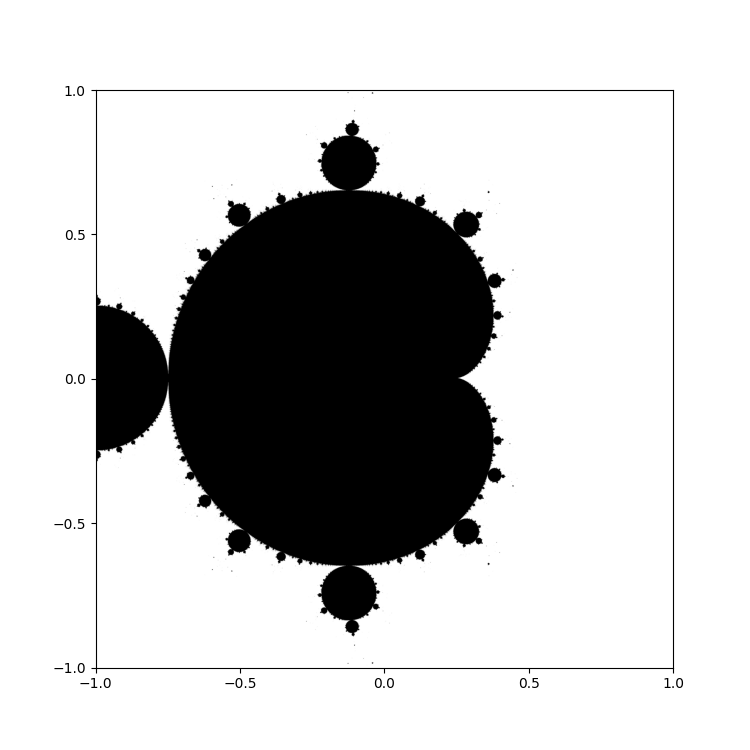

In [60]:
plt.close('all')
fig, ax = plt.subplots(figsize=(7.5, 7.5))
fig.canvas.header_visible = False
fig.canvas.toolbar_visible = False
ax.imshow(grid, extent=(re_min, re_max, im_min, im_max), cmap='binary', origin="lower")
ax.set_xticks(np.linspace(re_min, re_max, 5))
ax.set_yticks(np.linspace(im_min, im_max, 5))
ax.set_aspect('equal')
plt.title("")
plt.show()

## Dynamic zoom WIP

Slightly less detailed MandelbrotSet instance.

In [61]:
ms = MandelbrotSet(1000, 2000)

_THIS_ is in fact ChatGPT'd stuff more or less start to finish.. But it works.

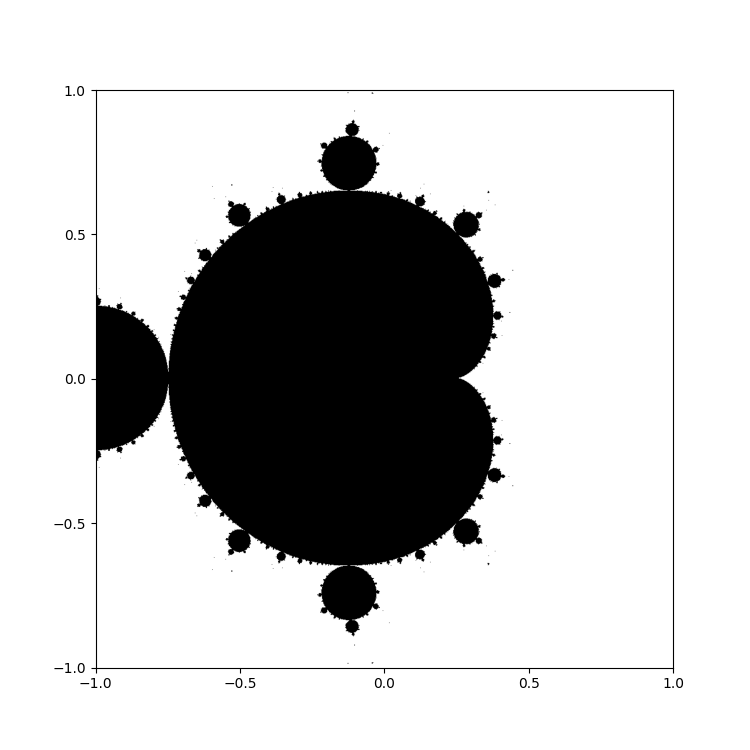

In [62]:
plt.close('all') 

# Initial bounds
re_min, re_max, im_min, im_max = -1, 1, -1, 1

fig, ax = plt.subplots(figsize=(7.5, 7.5))
fig.canvas.header_visible = False
fig.canvas.toolbar_visible = False

# Initial grid
grid = ms.make_grid(re_min, re_max, im_min, im_max)

img = ax.imshow(
    grid,
    extent=(re_min, re_max, im_min, im_max),
    cmap='binary',
    origin="lower"
)

ax.set_xticks(np.linspace(re_min, re_max, 5))
ax.set_yticks(np.linspace(im_min, im_max, 5))
ax.set_aspect('equal')


def redraw(re_min, re_max, im_min, im_max):
    global img

    # Recompute grid
    grid = ms.make_grid(re_min, re_max, im_min, im_max)

    # Update image instead of recreating (faster)
    img.set_data(grid)
    img.set_extent((re_min, re_max, im_min, im_max))

    # Update ticks
    ax.set_xticks(np.linspace(re_min, re_max, 5))
    ax.set_yticks(np.linspace(im_min, im_max, 5))

    fig.canvas.draw_idle()


def onselect(eclick, erelease):
    global re_min, re_max, im_min, im_max

    x1, x2 = eclick.xdata, erelease.xdata
    y1, y2 = eclick.ydata, erelease.ydata

    if None in (x1, x2, y1, y2):
        return

    xmin, xmax = sorted([x1, x2])
    ymin, ymax = sorted([y1, y2])

    width = xmax - xmin
    height = ymax - ymin

    # Force square
    size = min(width, height)
    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2

    re_min = cx - size / 2
    re_max = cx + size / 2
    im_min = cy - size / 2
    im_max = cy + size / 2

    redraw(re_min, re_max, im_min, im_max)

    # 👇 Hide selection box after use
    rect_selector.set_visible(False)
    fig.canvas.draw_idle()


# Rectangle selector
rect_selector = RectangleSelector(
    ax,
    onselect,
    button=[1],
    useblit=True,
    interactive=True
)

plt.show()